# DonorCast — Task 1.3: Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the Malaysian blood donation dataset (`data/processed/long.parquet` and `data/raw/donations_state.csv`) spanning **2006-01-01 to 2026-09-22**.

### Scope of Analysis
1. **National daily donations (2006–2026)** with a 28-day rolling mean.
2. **Yearly totals** bar chart and secular trends.
3. **Day-of-week profile** (National vs representative states with varying weekend regimes).
4. **Yearly seasonality**: mean donations by ISO week of year.
5. **Holiday event windows**: trajectory from 14 days before to 14 days after *Hari Raya Aidilfitri*, *Chinese New Year*, and *Deepavali*.
6. **Facility profiles**: mean daily volume, zero-donation day shares, and temporal coverage.
7. **Blood group distribution**: overall ABO proportions and facility breakdowns.
8. **National zero-donation days**: complete inventory and anomaly inspection.
9. **2019 vs 2020 monthly comparison**: impact of COVID-19 Movement Control Orders (MCO).

All figures are automatically saved to `reports/figures/` as PNG files. Every chart includes an evidence-based markdown takeaway derived directly from the data.


In [1]:
from pathlib import Path

import holidays
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib import ticker

# Configure plot styling
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

# Output paths
FIGURES_DIR = (
    Path("../reports/figures")
    if Path("../reports/figures").exists() or not Path("reports/figures").exists()
    else Path("reports/figures")
)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load datasets
long_path = (
    Path("../data/processed/long.parquet")
    if Path("../data/processed/long.parquet").exists()
    else Path("data/processed/long.parquet")
)
state_path = (
    Path("../data/raw/donations_state.csv")
    if Path("../data/raw/donations_state.csv").exists()
    else Path("data/raw/donations_state.csv")
)

df_long = pd.read_parquet(long_path)
df_state = pd.read_csv(state_path)

print(
    f"Loaded long.parquet: {len(df_long):,} rows across {df_long['facility'].nunique()} facilities."
)
print(
    f"Loaded donations_state.csv: {len(df_state):,} rows across {df_state['state'].nunique()} states/regions."
)

Loaded long.parquet: 666,160 rows across 22 facilities.
Loaded donations_state.csv: 105,980 rows across 14 states/regions.


2006 daily mean donations: 599.7
2025 daily mean donations: 1616.0
2026 daily mean donations (through Sep 22): 1660.5
Volume growth ratio (2025 vs 2006): 2.69x


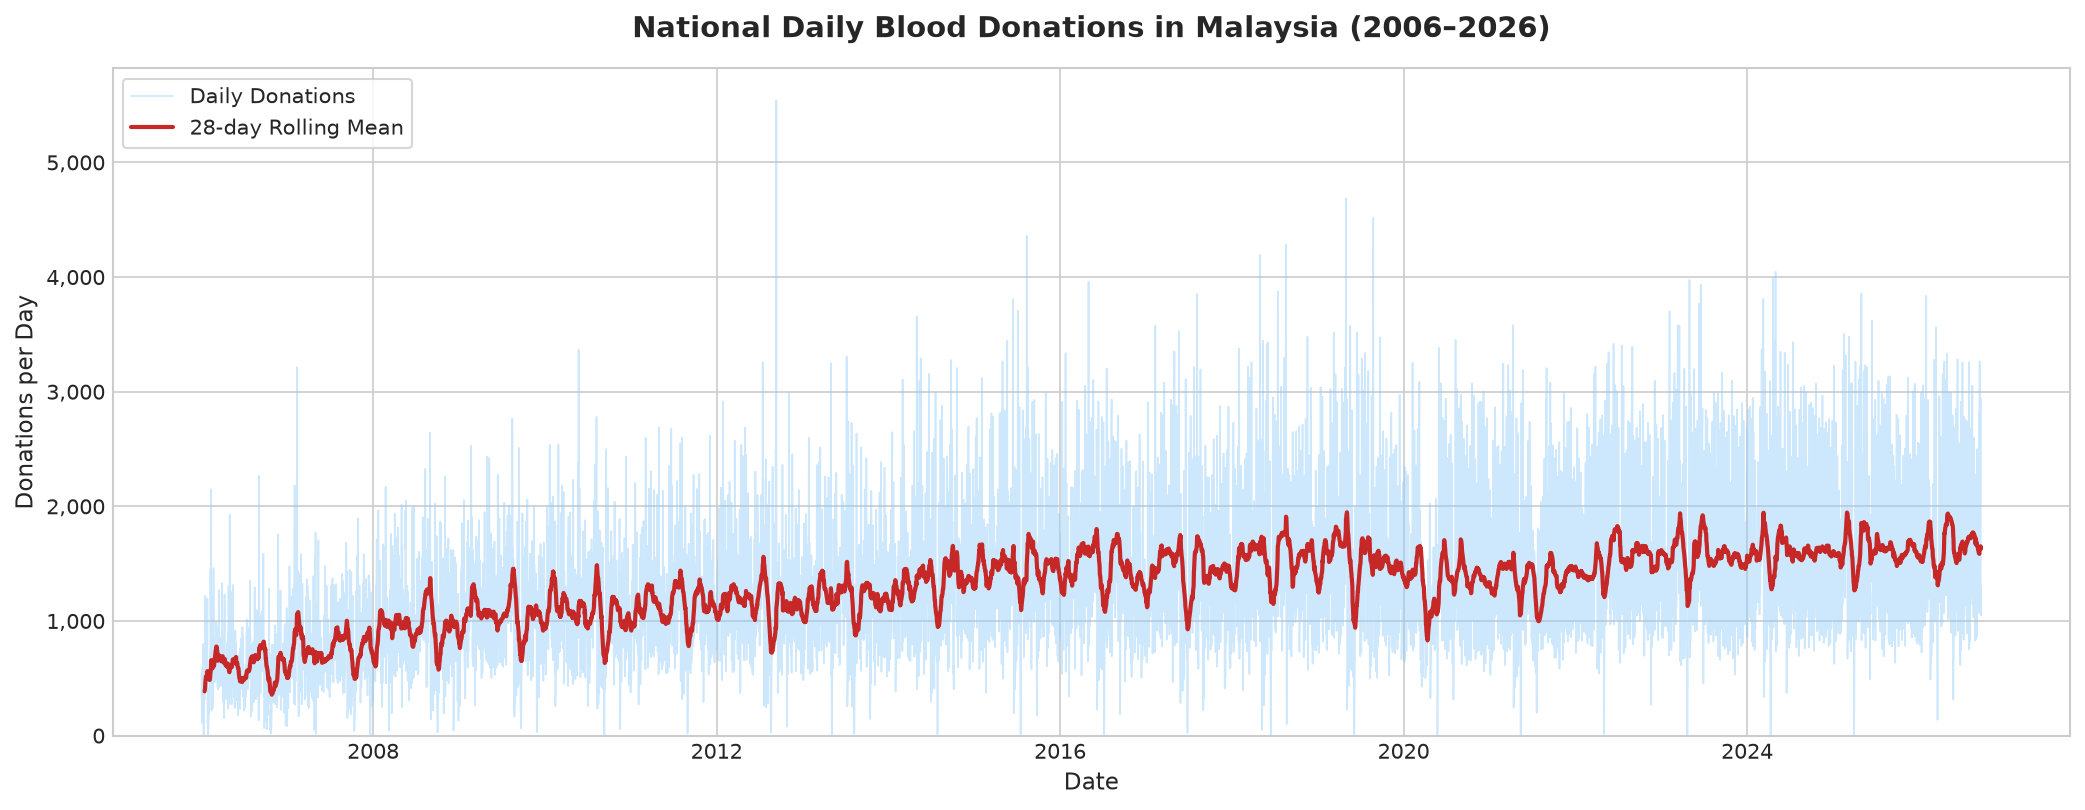

In [2]:
# 1. National Daily Donations (2006-2026) with 28-day Rolling Mean
nat_daily = df_long.groupby("date")["donations"].sum().reset_index()
nat_daily["date"] = pd.to_datetime(nat_daily["date"])
nat_daily = nat_daily.sort_values("date").reset_index(drop=True)
nat_daily["rolling_28d"] = (
    nat_daily["donations"].rolling(window=28, min_periods=14, center=False).mean()
)

# Compute summary metrics for takeaway
nat_daily["year"] = nat_daily["date"].dt.year
mean_2006 = nat_daily[nat_daily["year"] == 2006]["donations"].mean()
mean_2025 = nat_daily[nat_daily["year"] == 2025]["donations"].mean()
mean_2026 = nat_daily[nat_daily["year"] == 2026]["donations"].mean()
growth_ratio = mean_2025 / mean_2006

print(f"2006 daily mean donations: {mean_2006:.1f}")
print(f"2025 daily mean donations: {mean_2025:.1f}")
print(f"2026 daily mean donations (through Sep 22): {mean_2026:.1f}")
print(f"Volume growth ratio (2025 vs 2006): {growth_ratio:.2f}x")

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.plot(
    nat_daily["date"],
    nat_daily["donations"],
    color="#90caf9",
    alpha=0.45,
    linewidth=0.8,
    label="Daily Donations",
)
ax.plot(
    nat_daily["date"],
    nat_daily["rolling_28d"],
    color="#c62828",
    linewidth=2.0,
    label="28-day Rolling Mean",
)

ax.set_title("National Daily Blood Donations in Malaysia (2006–2026)", pad=15)
ax.set_xlabel("Date")
ax.set_ylabel("Donations per Day")
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_ylim(bottom=0)
ax.legend(loc="upper left", frameon=True)
plt.tight_layout()

fig_path_1 = FIGURES_DIR / "01_national_daily_trend.png"
plt.savefig(fig_path_1)
plt.show()

**Takeaway (Figure 1):** National daily donations expanded steadily from 599.7 donations/day in 2006 to 1,616.0 donations/day in 2025 (a 2.69× volume increase, with 2026 averaging 1,660.5 donations/day through Sep 22), exhibiting pronounced recurring annual dips during festive holiday seasons and sharp volatility during early 2020 COVID lockdowns.


2006 annual total: 218,887
2025 annual total (peak): 589,834
2020 annual total (COVID shock): 497,574
2021 annual total (COVID shock): 499,745
2018–2025 annual range: 497,574 to 589,834 (non-COVID years: 559,800 to 589,834)


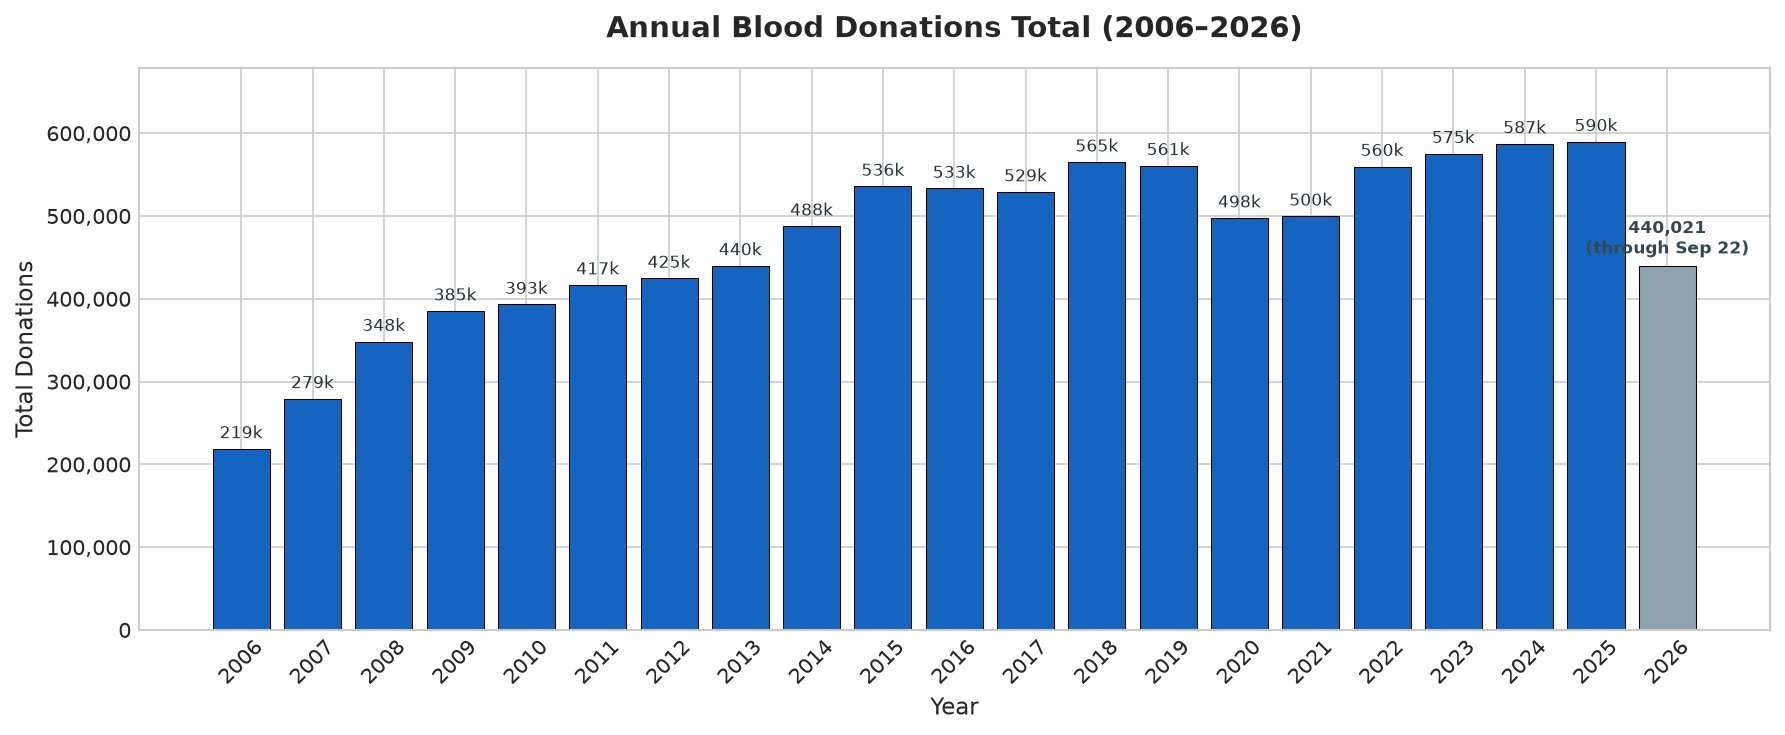

In [3]:
# 2. Yearly Totals Bar Chart
yearly_stats = (
    nat_daily.groupby("year")["donations"].agg(total="sum", days="count", mean="mean").reset_index()
)

tot_2006 = yearly_stats.loc[yearly_stats["year"] == 2006, "total"].values[0]
tot_2025 = yearly_stats.loc[yearly_stats["year"] == 2025, "total"].values[0]
tot_2020 = yearly_stats.loc[yearly_stats["year"] == 2020, "total"].values[0]
tot_2021 = yearly_stats.loc[yearly_stats["year"] == 2021, "total"].values[0]
stats_18_25 = yearly_stats[(yearly_stats["year"] >= 2018) & (yearly_stats["year"] <= 2025)]
min_18_25 = stats_18_25["total"].min()
max_18_25 = stats_18_25["total"].max()
non_covid_18_25 = stats_18_25[~stats_18_25["year"].isin([2020, 2021])]
min_non_covid_18_25 = non_covid_18_25["total"].min()
max_non_covid_18_25 = non_covid_18_25["total"].max()

print(f"2006 annual total: {tot_2006:,}")
print(f"2025 annual total (peak): {tot_2025:,}")
print(f"2020 annual total (COVID shock): {tot_2020:,}")
print(f"2021 annual total (COVID shock): {tot_2021:,}")
print(
    f"2018–2025 annual range: {min_18_25:,} to {max_18_25:,} (non-COVID years: {min_non_covid_18_25:,} to {max_non_covid_18_25:,})"
)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#1565c0" if y < 2026 else "#90a4ae" for y in yearly_stats["year"]]
bars = ax.bar(
    yearly_stats["year"], yearly_stats["total"], color=colors, edgecolor="black", linewidth=0.5
)

for bar, year, tot in zip(bars, yearly_stats["year"], yearly_stats["total"]):
    if year == 2026:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 8000,
            f"{tot:,.0f}\n(through Sep 22)",
            ha="center",
            va="bottom",
            fontsize=8,
            color="#37474f",
            fontweight="bold",
        )
    else:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 8000,
            f"{tot / 1e3:.0f}k",
            ha="center",
            va="bottom",
            fontsize=8,
            color="#263238",
        )

ax.set_title("Annual Blood Donations Total (2006–2026)", pad=15)
ax.set_xlabel("Year")
ax.set_ylabel("Total Donations")
ax.set_xticks(yearly_stats["year"])
ax.set_xticklabels(yearly_stats["year"], rotation=45)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.set_ylim(0, yearly_stats["total"].max() * 1.15)
plt.tight_layout()

fig_path_2 = FIGURES_DIR / "02_yearly_totals.png"
plt.savefig(fig_path_2)
plt.show()

**Takeaway (Figure 2):** Annual collections grew from 218,887 in 2006 to a peak of 589,834 in 2025. Across the 2018–2025 period, annual volumes ranged between 497,574 and 589,834 (with non-COVID years holding consistently between 559,800 and 589,834, and temporary dips in 2020 at 497,574 and 2021 at 499,745 before full recovery).


Mean Daily Donations by Day of Week:
state              Malaysia  W.P. Kuala Lumpur  Johor  Kedah  Sabah
dow_num dow_name                                                   
0       Monday        866.8              311.1   61.5   88.5   50.1
1       Tuesday      1199.9              451.1   73.6  108.9   60.9
2       Wednesday    1352.2              500.9   85.0  116.4   72.4
3       Thursday     1302.9              499.2   75.8  110.0   64.8
4       Friday        894.9              369.3   26.5  115.8   56.3
5       Saturday     1409.5              547.5  105.5   90.8  103.8
6       Sunday       2098.6              716.5  214.8  143.2  114.6


C:\Users\akhil\AppData\Local\Temp\ipykernel_48976\260507578.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['M', 'Tu', 'W', 'Th', 'F', 'Sa', 'Su'])
C:\Users\akhil\AppData\Local\Temp\ipykernel_48976\260507578.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['M', 'Tu', 'W', 'Th', 'F', 'Sa', 'Su'])
C:\Users\akhil\AppData\Local\Temp\ipykernel_48976\260507578.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['M', 'Tu', 'W', 'Th', 'F', 'Sa', 'Su'])
C:\Users\akhil\AppData\Local\Temp\ipykernel_48976\260507578.py:26: UserWarning: set_ticklabels() should only be used with

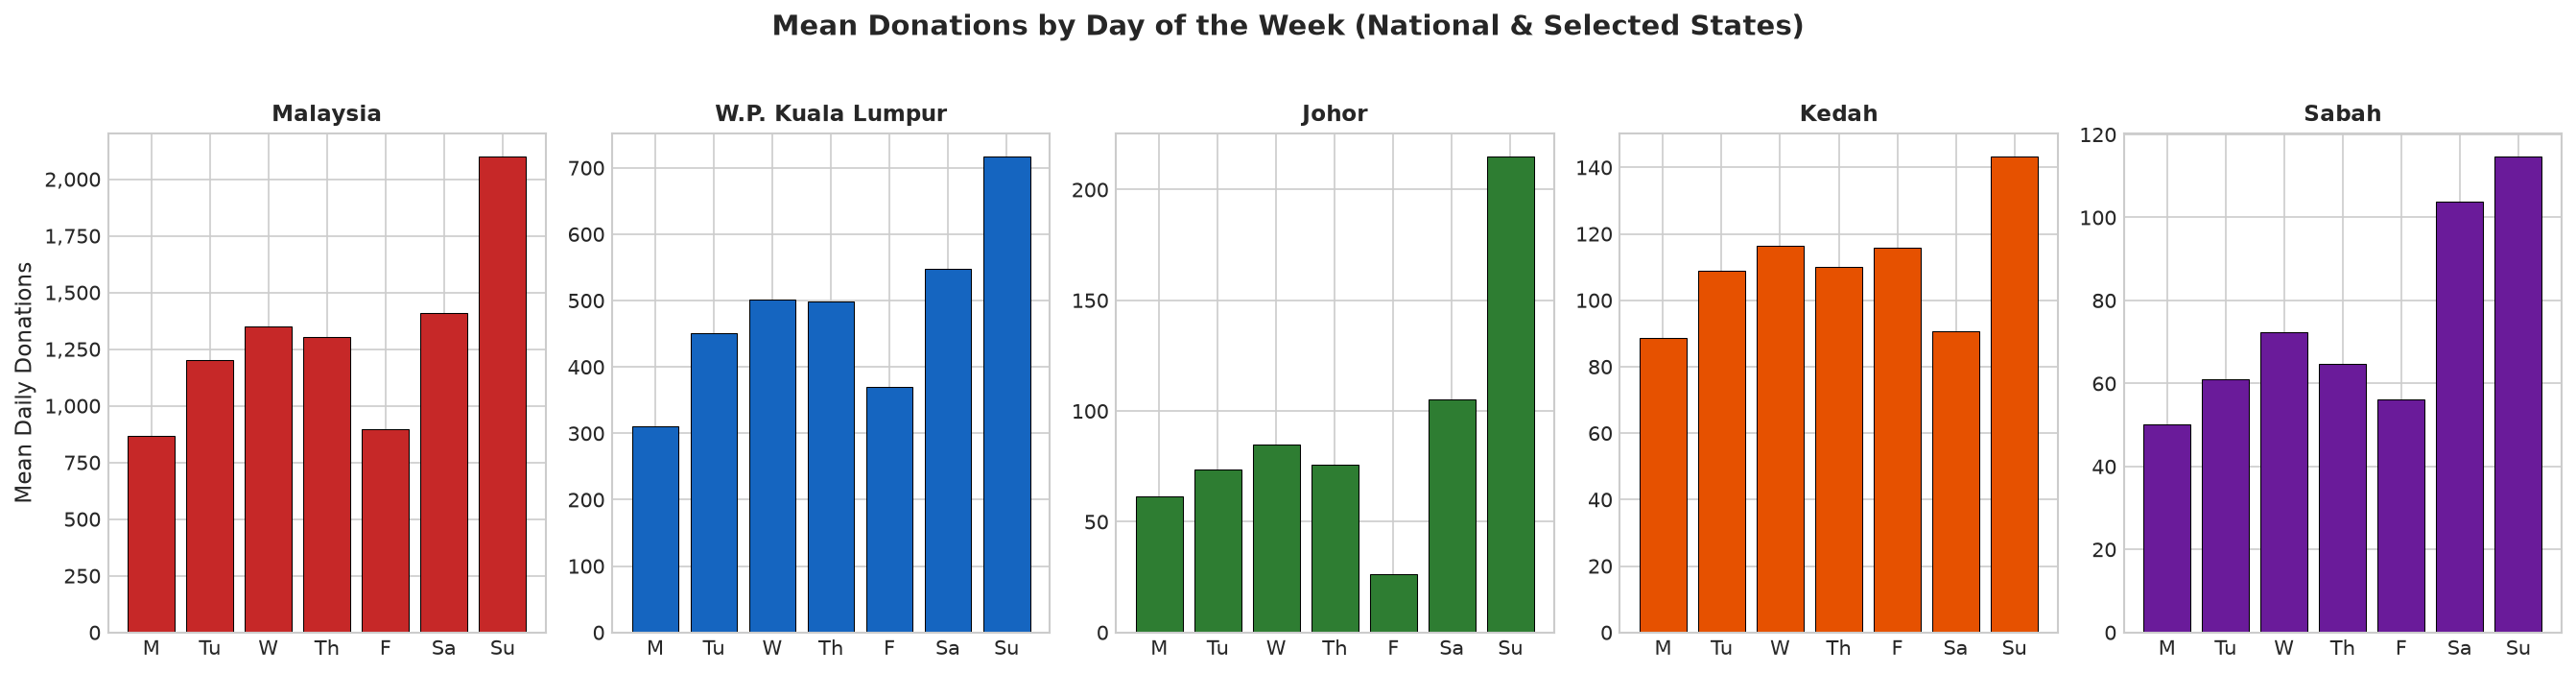

In [4]:
# 3. Mean Donations by Day of Week (National and 4 Example States)
df_state_dow = df_state.copy()
df_state_dow["date"] = pd.to_datetime(df_state_dow["date"])
df_state_dow["dow_name"] = df_state_dow["date"].dt.day_name()
df_state_dow["dow_num"] = df_state_dow["date"].dt.dayofweek

states_focus = ["Malaysia", "W.P. Kuala Lumpur", "Johor", "Kedah", "Sabah"]
dow_names = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dow_df = df_state_dow[df_state_dow["state"].isin(states_focus)].copy()
dow_summary = dow_df.groupby(["state", "dow_num", "dow_name"])["daily"].mean().reset_index()

# Print formatted summary table for transparency
dow_table = (
    dow_df.groupby(["dow_num", "dow_name", "state"])["daily"]
    .mean()
    .unstack(level="state")[states_focus]
)
print("Mean Daily Donations by Day of Week:")
print(dow_table.round(1).to_string())

fig, axes = plt.subplots(1, 5, figsize=(18, 4.5), sharey=False)
palette = {
    "Malaysia": "#c62828",
    "W.P. Kuala Lumpur": "#1565c0",
    "Johor": "#2e7d32",
    "Kedah": "#e65100",
    "Sabah": "#6a1b9a",
}

for i, state in enumerate(states_focus):
    ax = axes[i]
    state_data = dow_summary[dow_summary["state"] == state].sort_values("dow_num")
    bars = ax.bar(
        state_data["dow_name"],
        state_data["daily"],
        color=palette[state],
        edgecolor="black",
        linewidth=0.5,
    )
    ax.set_title(state, fontsize=11, fontweight="bold")
    ax.set_xticklabels(["M", "Tu", "W", "Th", "F", "Sa", "Su"])
    ax.set_xlabel("")
    ax.set_ylabel("Mean Daily Donations" if i == 0 else "")
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

fig.suptitle(
    "Mean Donations by Day of the Week (National & Selected States)",
    fontsize=14,
    fontweight="bold",
    y=1.03,
)
plt.tight_layout()

fig_path_3 = FIGURES_DIR / "03_day_of_week_distribution.png"
plt.savefig(fig_path_3, bbox_inches="tight")
plt.show()

**Takeaway (Figure 3):** Nationally, collections peak on Sunday (mean: 2,098.6 donations/day) and trough on Monday (866.8) and Friday (894.9). Across states, weekday patterns differ markedly: Kedah collections peak on Sunday (143.2), Wednesday (116.4), and Friday (115.8), with Monday (88.5) and Saturday (90.8) as lower days, whereas Johor, Sabah, and KL peak on Sunday (214.8, 114.6, and 716.5 respectively) with Johor troughing sharply on Friday (26.5). These weekday variations are associated with regional weekend conventions and Friday prayers, but causality is not proven by this chart.


Top 5 highest donation weeks (ISO week, mean daily donations):
  Week 3: 1437.6 donations/day (std: 561.8)
  Week 20: 1426.2 donations/day (std: 733.8)
  Week 10: 1426.0 donations/day (std: 718.8)
  Week 24: 1425.5 donations/day (std: 770.5)
  Week 8: 1424.1 donations/day (std: 618.9)

Bottom 5 lowest donation weeks (ISO week, mean daily donations):
  Week 52: 1080.3 donations/day (std: 527.9)
  Week 1: 1145.2 donations/day (std: 638.7)
  Week 23: 1160.2 donations/day (std: 685.5)
  Week 22: 1175.7 donations/day (std: 643.8)
  Week 51: 1192.9 donations/day (std: 491.6)


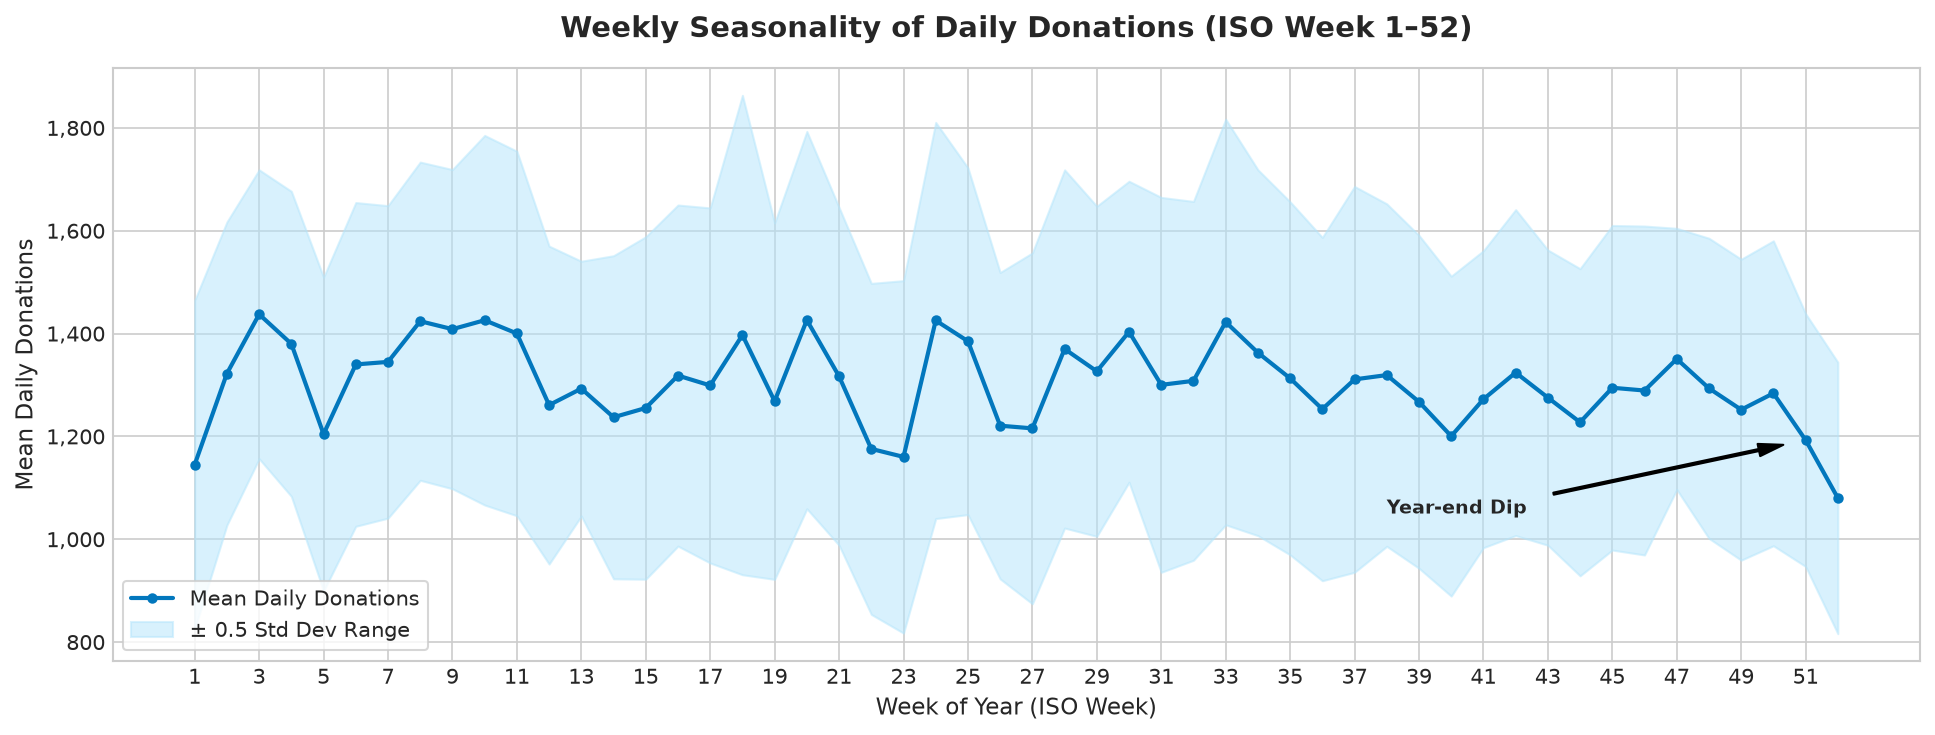

In [5]:
# 4. Seasonality: Mean Donations by Week of Year
nat_daily["week"] = nat_daily["date"].dt.isocalendar().week.astype(int)
weekly_seasonality = (
    nat_daily[nat_daily["week"] <= 52]
    .groupby("week")["donations"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

top_weeks = weekly_seasonality.sort_values("mean", ascending=False).head(5)
bottom_weeks = weekly_seasonality.sort_values("mean", ascending=True).head(5)

print("Top 5 highest donation weeks (ISO week, mean daily donations):")
for _, r in top_weeks.iterrows():
    print(f"  Week {int(r['week'])}: {r['mean']:.1f} donations/day (std: {r['std']:.1f})")

print("\nBottom 5 lowest donation weeks (ISO week, mean daily donations):")
for _, r in bottom_weeks.iterrows():
    print(f"  Week {int(r['week'])}: {r['mean']:.1f} donations/day (std: {r['std']:.1f})")

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(
    weekly_seasonality["week"],
    weekly_seasonality["mean"],
    color="#0277bd",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Mean Daily Donations",
)
ax.fill_between(
    weekly_seasonality["week"],
    weekly_seasonality["mean"] - 0.5 * weekly_seasonality["std"],
    weekly_seasonality["mean"] + 0.5 * weekly_seasonality["std"],
    color="#b3e5fc",
    alpha=0.5,
    label="± 0.5 Std Dev Range",
)

# Annotations for major seasonal phases
ax.annotate(
    "Year-end Dip",
    xy=(51, weekly_seasonality.loc[weekly_seasonality["week"] == 51, "mean"].values[0]),
    xytext=(38, 1050),
    arrowprops={"facecolor": "black", "shrink": 0.08, "width": 1, "headwidth": 6},
    fontsize=9,
    fontweight="bold",
)

ax.set_title("Weekly Seasonality of Daily Donations (ISO Week 1–52)", pad=15)
ax.set_xlabel("Week of Year (ISO Week)")
ax.set_ylabel("Mean Daily Donations")
ax.set_xticks(range(1, 53, 2))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(loc="lower left", frameon=True)
plt.tight_layout()

fig_path_4 = FIGURES_DIR / "04_weekly_seasonality.png"
plt.savefig(fig_path_4)
plt.show()

**Takeaway (Figure 4):** Mean daily donations reach their highest levels early in the year (Week 3: 1,437.6 donations/day) and around mid-year (Week 20: 1,426.2, Week 10: 1,426.0, Week 24: 1,425.5, Week 8: 1,424.1 donations/day). The lowest mean daily volumes occur during the year-end holiday weeks (Week 52: 1,080.3, Week 51: 1,192.9 donations/day), at the start of the year (Week 1: 1,145.2 donations/day), and during Weeks 22–23 (1,160.2–1,175.7 donations/day).


=== Festival Dates by Year (2006–2026) ===

Hari Raya Aidilfitri (21 occurrences):
  2006: 2006-10-24 (Tuesday)
  2007: 2007-10-13 (Saturday)
  2008: 2008-10-01 (Wednesday)
  2009: 2009-09-20 (Sunday)
  2010: 2010-09-10 (Friday)
  2011: 2011-08-31 (Wednesday)
  2012: 2012-08-19 (Sunday)
  2013: 2013-08-08 (Thursday)
  2014: 2014-07-28 (Monday)
  2015: 2015-07-17 (Friday)
  2016: 2016-07-06 (Wednesday)
  2017: 2017-06-25 (Sunday)
  2018: 2018-06-15 (Friday)
  2019: 2019-06-05 (Wednesday)
  2020: 2020-05-24 (Sunday)
  2021: 2021-05-13 (Thursday)
  2022: 2022-05-02 (Monday)
  2023: 2023-04-22 (Saturday)
  2024: 2024-04-10 (Wednesday)
  2025: 2025-03-31 (Monday)
  2026: 2026-03-21 (Saturday)

Chinese New Year (21 occurrences):
  2006: 2006-01-29 (Sunday)
  2007: 2007-02-18 (Sunday)
  2008: 2008-02-07 (Thursday)
  2009: 2009-01-26 (Monday)
  2010: 2010-02-14 (Sunday)
  2011: 2011-02-03 (Thursday)
  2012: 2012-01-23 (Monday)
  2013: 2013-02-10 (Sunday)
  2014: 2014-01-31 (Friday)
  2015: 201

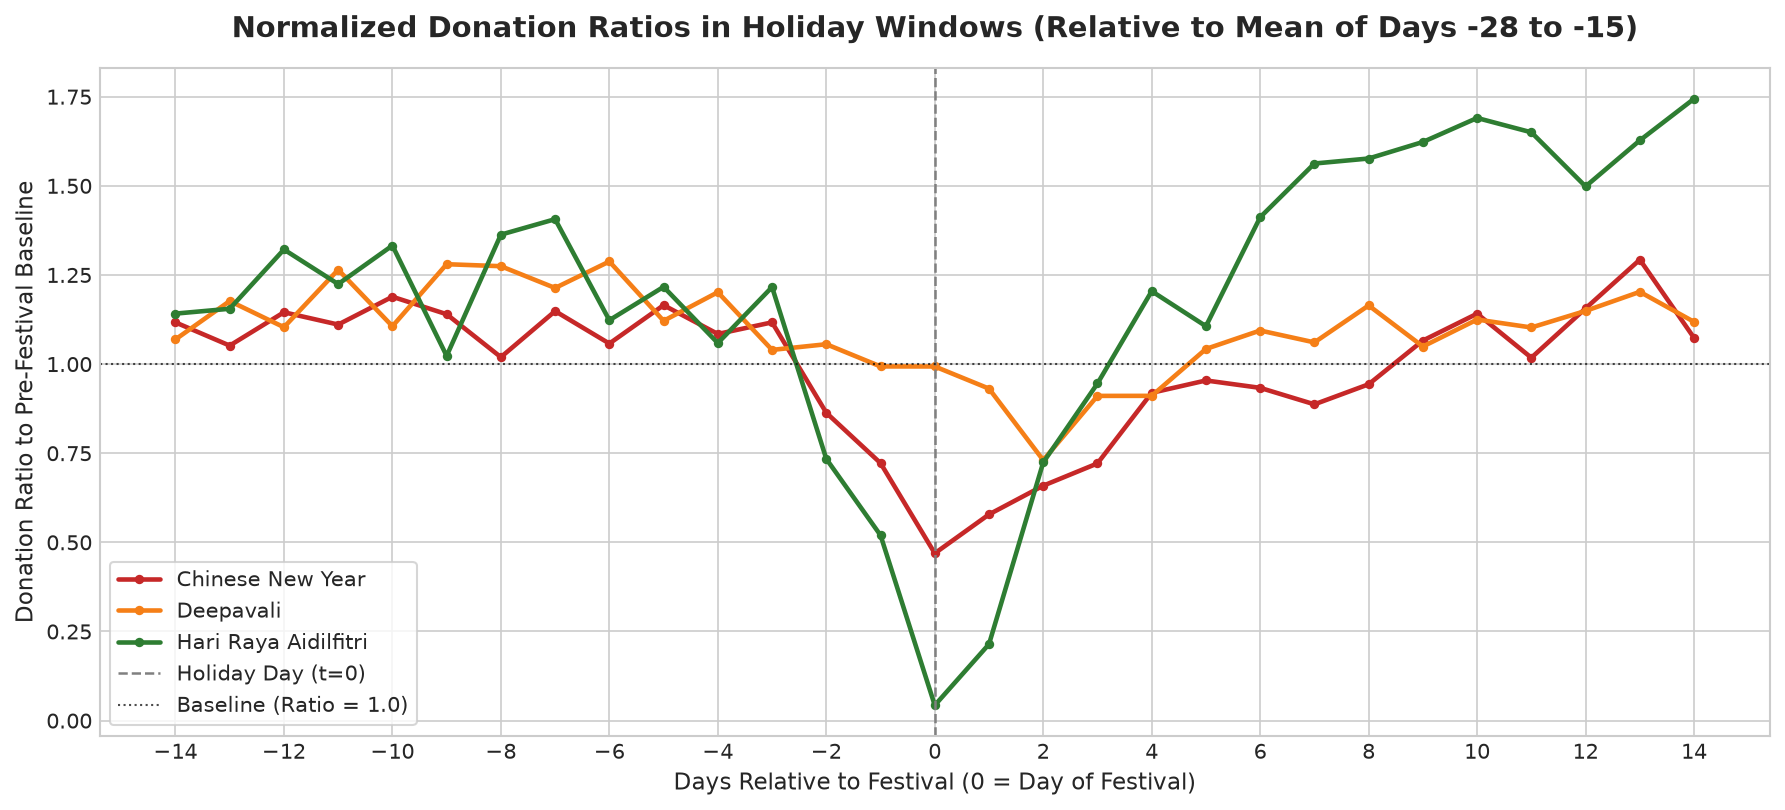

In [6]:
# 5. Holiday Windows: Replot Event Windows as Ratio to Pre-Event Baseline (-28 to -15 Days)
my_holidays = holidays.Malaysia(subdiv="KUL", years=range(2006, 2027))

holiday_events = {"Hari Raya Aidilfitri": [], "Chinese New Year": [], "Deepavali": []}

for dt, name in sorted(my_holidays.items()):
    # Filter to main 1st day holiday instances
    if (
        "Hari Raya Puasa" in name
        and "Hari Kedua" not in name
        and "Cuti" not in name
        and "pergantian" not in name
    ):
        holiday_events["Hari Raya Aidilfitri"].append(pd.to_datetime(dt))
    elif "Tahun Baharu Cina" in name and "Hari Kedua" not in name and "Cuti" not in name:
        holiday_events["Chinese New Year"].append(pd.to_datetime(dt))
    elif "Deepavali" in name and "Cuti" not in name:
        holiday_events["Deepavali"].append(pd.to_datetime(dt))

# Print each festival's dates for every year
print("=== Festival Dates by Year (2006–2026) ===")
for h_name, h_dates in holiday_events.items():
    print(f"\n{h_name} ({len(h_dates)} occurrences):")
    for d in h_dates:
        print(f"  {d.year}: {d.strftime('%Y-%m-%d')} ({d.day_name()})")

# Compute baseline (-28 to -15 days) and ratio per event window
daily_indexed = nat_daily.set_index("date")["donations"]
ratio_records = []

for h_name, h_dates in holiday_events.items():
    for h_date in h_dates:
        # Pre-event baseline: mean of days -28 to -15 (inclusive, 14 days)
        baseline_dates = [h_date + pd.Timedelta(days=off) for off in range(-28, -14)]
        valid_baseline = [
            daily_indexed.loc[bd] for bd in baseline_dates if bd in daily_indexed.index
        ]

        if len(valid_baseline) >= 7:  # ensure sufficient baseline data
            base_mean = np.mean(valid_baseline)
            for offset in range(-14, 15):
                target_date = h_date + pd.Timedelta(days=offset)
                if target_date in daily_indexed.index:
                    ratio_records.append(
                        {
                            "holiday": h_name,
                            "event_date": h_date,
                            "offset": offset,
                            "donations": daily_indexed.loc[target_date],
                            "ratio": daily_indexed.loc[target_date] / base_mean,
                        }
                    )

df_ratios = pd.DataFrame(ratio_records)
avg_ratios = df_ratios.groupby(["holiday", "offset"])["ratio"].mean().reset_index()

print("\n=== Holiday Window Ratio Summary (Relative to Baseline Days -28 to -15) ===")
for h_name in holiday_events:
    sub = avg_ratios[avg_ratios["holiday"] == h_name]
    min_row = sub.loc[sub["ratio"].idxmin()]
    t0_ratio = sub.loc[sub["offset"] == 0, "ratio"].values[0]
    print(f"{h_name}:")
    print(f"  Minimum ratio: {min_row['ratio']:.3f} at offset {int(min_row['offset']):+d} days")
    print(f"  Ratio at t=0 (festival day): {t0_ratio:.3f}")
    if h_name == "Deepavali":
        print("  Deepavali offsets -2 to +4 ratios:")
        for _, r in sub[sub["offset"].between(-2, 4)].iterrows():
            print(f"    Offset {int(r['offset']):+d}: ratio {r['ratio']:.3f}")

fig, ax = plt.subplots(figsize=(12, 5.5))
palette_h = {
    "Hari Raya Aidilfitri": "#2e7d32",
    "Chinese New Year": "#c62828",
    "Deepavali": "#f57f17",
}

for h_name, group in avg_ratios.groupby("holiday"):
    ax.plot(
        group["offset"],
        group["ratio"],
        label=h_name,
        color=palette_h[h_name],
        linewidth=2.2,
        marker="o",
        markersize=3.5,
    )

ax.axvline(0, color="gray", linestyle="--", linewidth=1.2, label="Holiday Day (t=0)")
ax.axhline(
    1.0, color="black", linestyle=":", linewidth=1.0, alpha=0.7, label="Baseline (Ratio = 1.0)"
)
ax.set_title(
    "Normalized Donation Ratios in Holiday Windows (Relative to Mean of Days -28 to -15)", pad=15
)
ax.set_xlabel("Days Relative to Festival (0 = Day of Festival)")
ax.set_ylabel("Donation Ratio to Pre-Festival Baseline")
ax.set_xticks(range(-14, 15, 2))
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax.legend(loc="lower left", frameon=True)
plt.tight_layout()

fig_path_5 = FIGURES_DIR / "05_holiday_windows.png"
plt.savefig(fig_path_5)
plt.show()

**Takeaway (Figure 5):** When normalized to each event's pre-holiday baseline (mean of days −28 to −15), donations drop dramatically during major festivals: Hari Raya Aidilfitri reaches its minimum at t=0 with an average ratio of 0.043 (a 95.7% drop from baseline) and remains suppressed across the surrounding fortnight; Chinese New Year drops to a minimum ratio of 0.469 at t=0 (a 53.1% drop); and Deepavali reaches its minimum at offset +2 days with an average ratio of 0.730 (a 27.0% drop) rather than at t=0 (ratio 0.993), as public holiday observance and replacement holidays often shift the trough 1–2 days after the festival date.


Pusat Darah Negara: mean daily = 485.1, zero-day share = 0.5%
Hospital Duchess of Kent: mean daily = 7.3, zero-day share = 67.5%

Full facility summary table:
                         facility  mean_daily  median_daily  zero_days  zero_share
               Pusat Darah Negara  485.051915         461.0         41    0.005416
        Hospital Sultanah Bahiyah  110.517834          86.0        190    0.025099
                  Hospital Melaka   74.842668          61.0        293    0.038705
   Hospital Tengku Ampuan Rahimah   68.283884          52.0        230    0.030383
  Hospital Raja Permaisuri Bainun   67.171731          53.0        945    0.124835
         Hospital Sultanah Aminah   66.396037          58.0       1187    0.156803
      Hospital Queen Elizabeth II   57.883355          45.0        287    0.037913
            Hospital Umum Sarawak   50.297754          36.0        740    0.097754
    Hospital Sultanah Nur Zahirah   45.860370          36.0       1000    0.132100
           

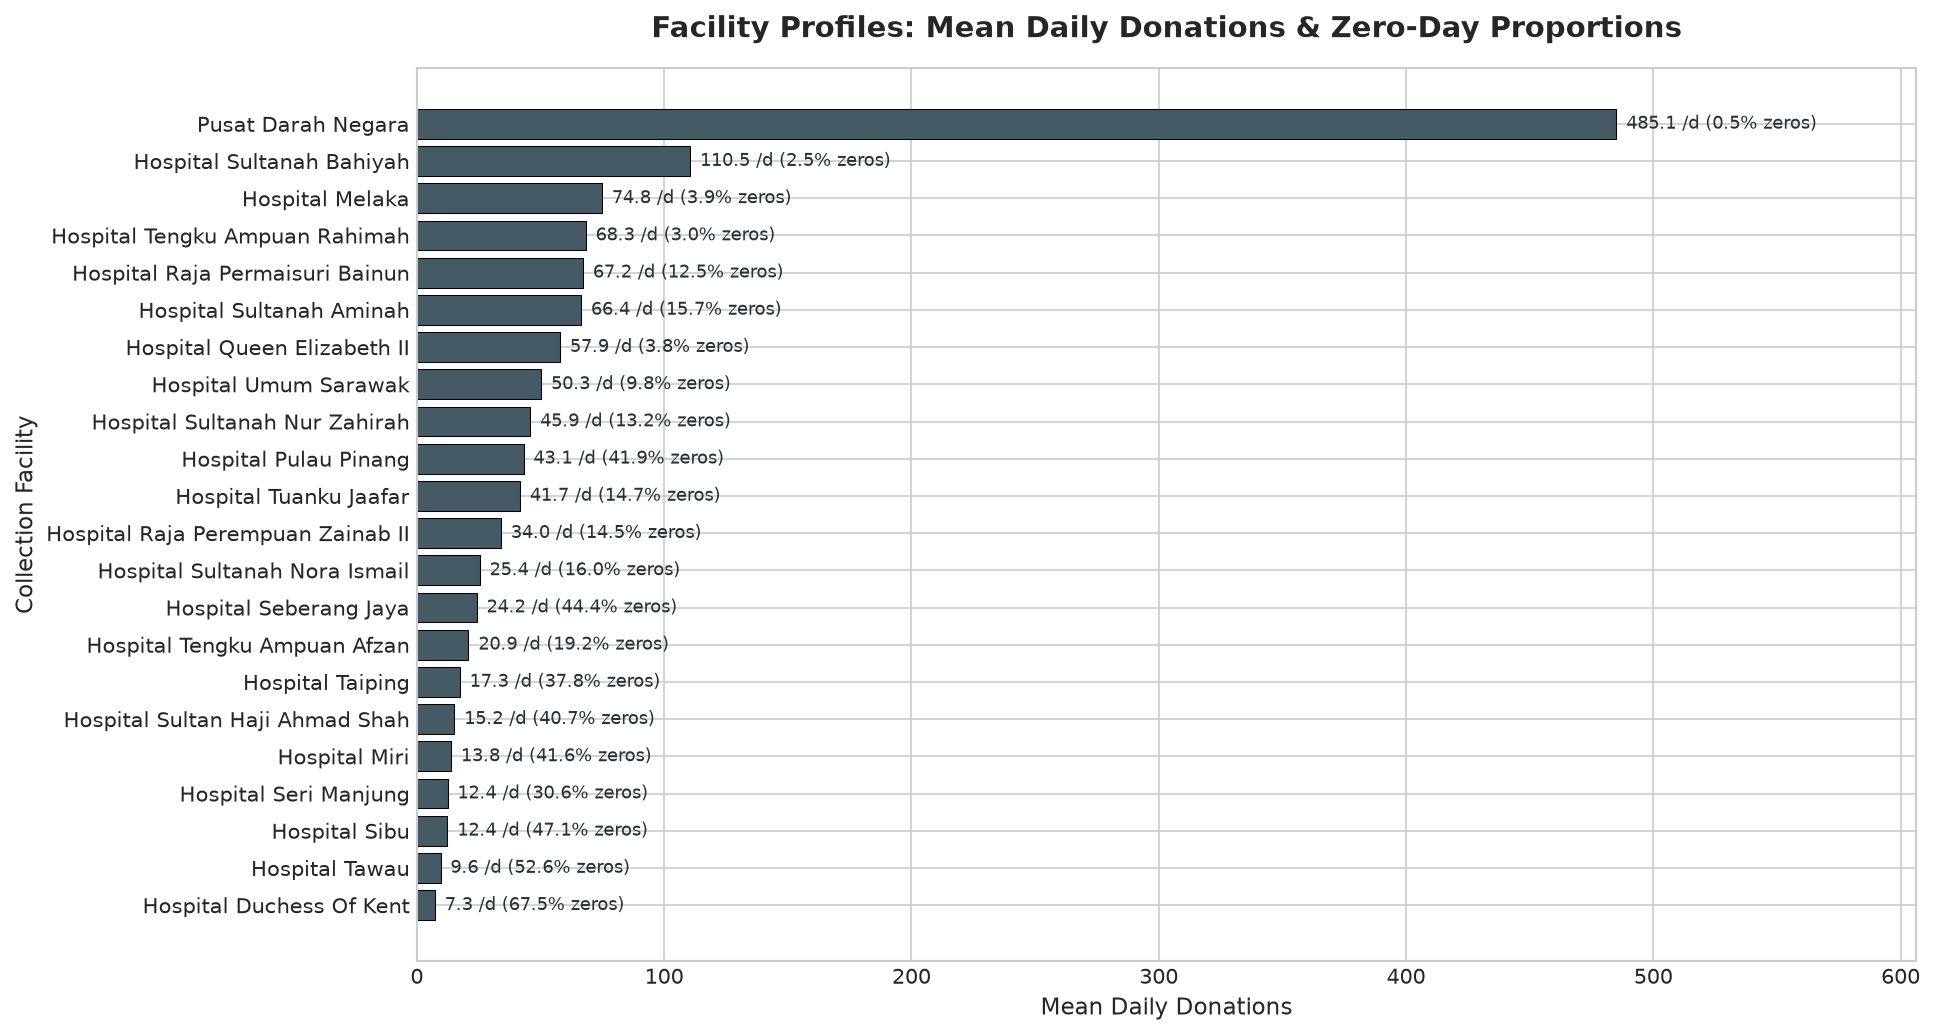

In [7]:
# 6. Per-Facility Table and Volume Profiles
fac_daily = df_long.groupby(["facility", "date"])["donations"].sum().reset_index()
fac_table = (
    fac_daily.groupby("facility")
    .agg(
        mean_daily=("donations", "mean"),
        median_daily=("donations", "median"),
        total_donations=("donations", "sum"),
        zero_days=("donations", lambda s: (s == 0).sum()),
        zero_share=("donations", lambda s: (s == 0).mean()),
        start_date=("date", "min"),
        end_date=("date", "max"),
    )
    .reset_index()
    .sort_values("mean_daily", ascending=False)
)

pdn = fac_table[fac_table["facility"].str.contains("Pusat Darah", case=False)].iloc[0]
dok = fac_table[fac_table["facility"].str.contains("Duchess", case=False)].iloc[0]

print(
    f"Pusat Darah Negara: mean daily = {pdn['mean_daily']:.1f}, zero-day share = {pdn['zero_share'] * 100:.1f}%"
)
print(
    f"Hospital Duchess of Kent: mean daily = {dok['mean_daily']:.1f}, zero-day share = {dok['zero_share'] * 100:.1f}%"
)
print("\nFull facility summary table:")
print(
    fac_table[["facility", "mean_daily", "median_daily", "zero_days", "zero_share"]].to_string(
        index=False
    )
)

# Plot facility distribution
fig, ax = plt.subplots(figsize=(13, 7))
sorted_facs = fac_table.sort_values("mean_daily", ascending=True)
bars = ax.barh(
    sorted_facs["facility"],
    sorted_facs["mean_daily"],
    color="#455a64",
    edgecolor="black",
    linewidth=0.5,
)

for bar, zero_pct in zip(bars, sorted_facs["zero_share"]):
    width = bar.get_width()
    ax.text(
        width + 4,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f} /d ({zero_pct * 100:.1f}% zeros)",
        va="center",
        ha="left",
        fontsize=8.5,
        color="#263238",
    )

ax.set_title("Facility Profiles: Mean Daily Donations & Zero-Day Proportions", pad=15)
ax.set_xlabel("Mean Daily Donations")
ax.set_ylabel("Collection Facility")
ax.set_xlim(0, fac_table["mean_daily"].max() * 1.25)
plt.tight_layout()

fig_path_6 = FIGURES_DIR / "06_facility_profiles.png"
plt.savefig(fig_path_6)
plt.show()

**Takeaway (Figure 6):** Collection volume is heavily skewed: Pusat Darah Negara dominates with 485.1 donations/day (0.5% zero days), while district centres like Hospital Duchess of Kent (Sandakan) average 7.3 donations/day with 67.5% zero-donation days, requiring zero-tolerant Tweedie/count-aware loss formulations.


National Blood Group Proportions:
  Group O: 41.85% (4,129,781 donations)
  Group B: 27.20% (2,683,628 donations)
  Group A: 24.82% (2,449,126 donations)
  Group AB: 6.13% (605,332 donations)


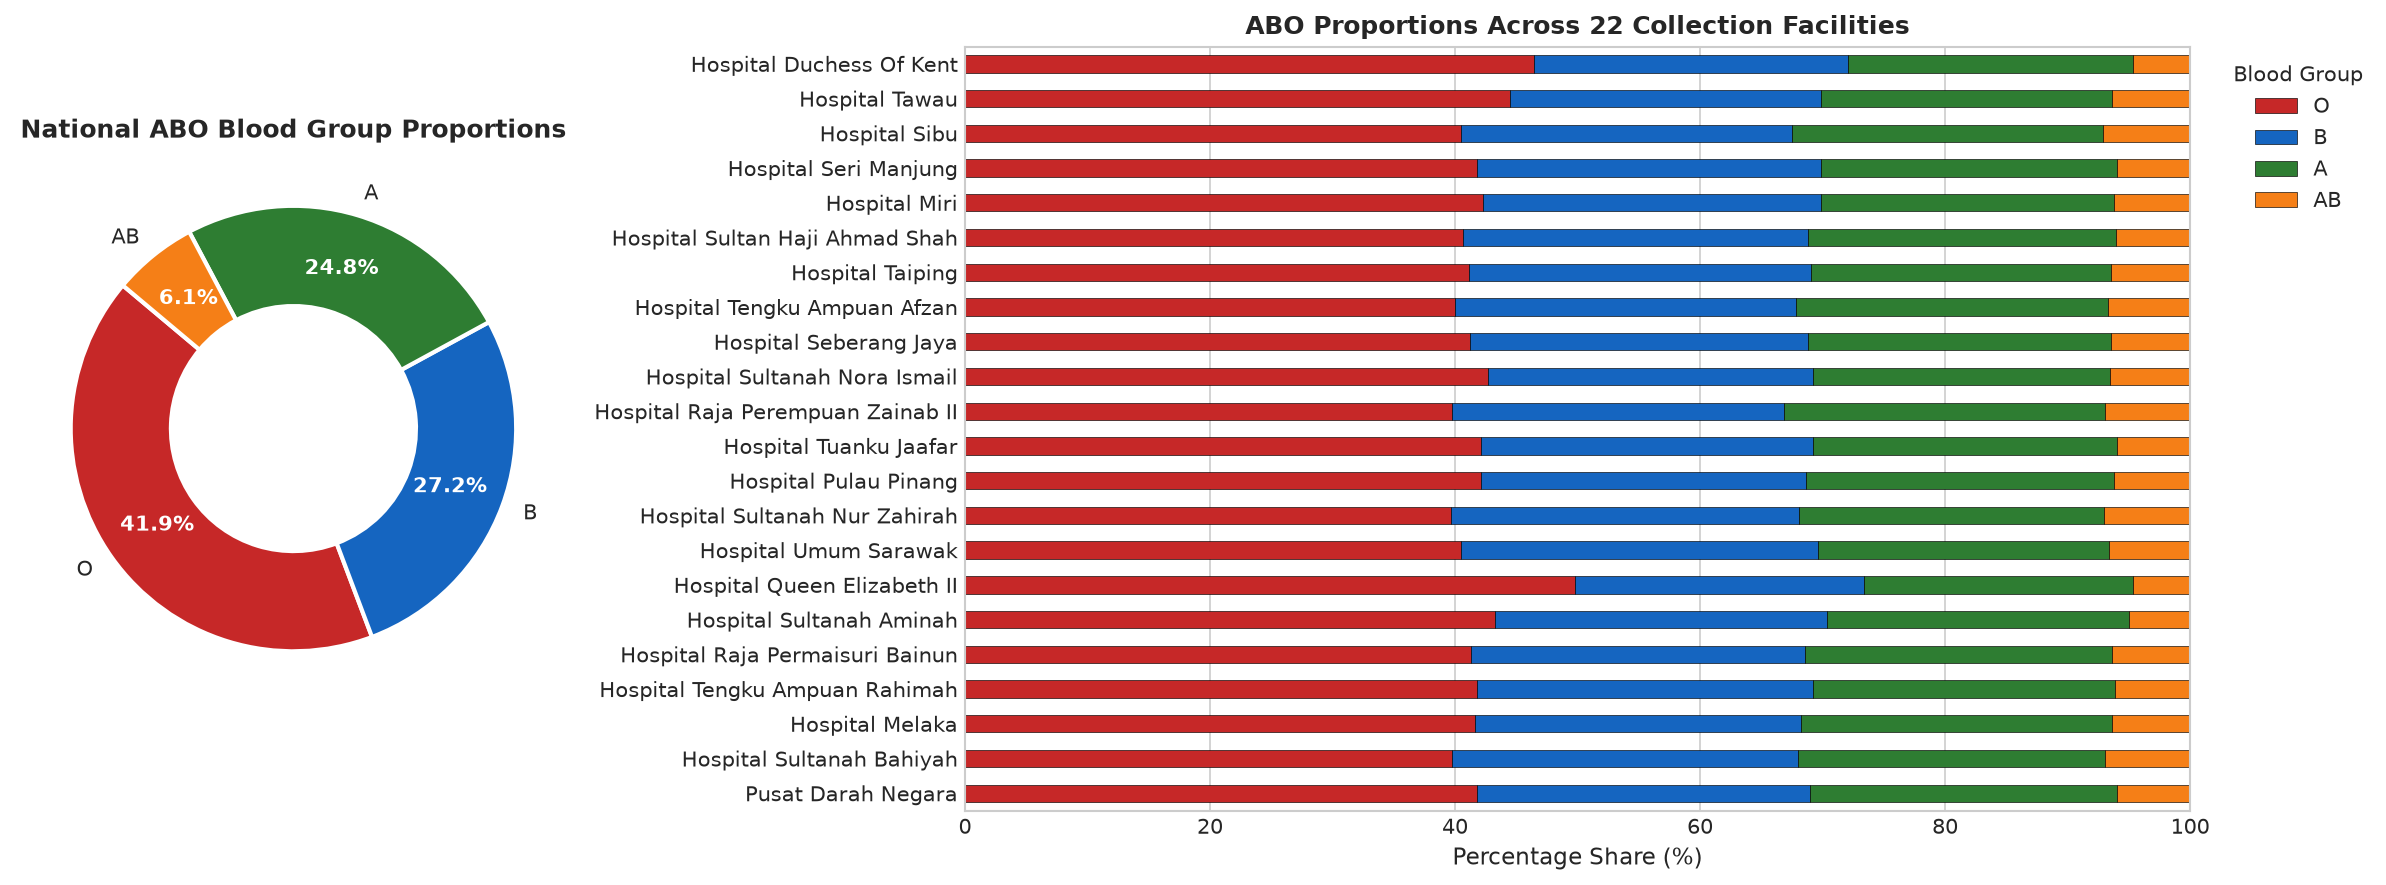

In [8]:
# 7. Blood Group Shares: Overall and by Facility
overall_abo = df_long.groupby("group")["donations"].sum()
overall_abo_pct = (overall_abo / overall_abo.sum() * 100).sort_values(ascending=False)

print("National Blood Group Proportions:")
for grp, pct in overall_abo_pct.items():
    tot = overall_abo[grp]
    print(f"  Group {grp}: {pct:.2f}% ({tot:,} donations)")

fac_abo = df_long.groupby(["facility", "group"])["donations"].sum().unstack()
fac_abo_pct = fac_abo.div(fac_abo.sum(axis=1), axis=0) * 100
fac_abo_pct = fac_abo_pct.loc[fac_table["facility"]]  # order by facility volume

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={"width_ratios": [1, 2.2]})

# Overall Donut Chart
colors_abo = {"O": "#c62828", "B": "#1565c0", "A": "#2e7d32", "AB": "#f57f17"}
ordered_groups = ["O", "B", "A", "AB"]
wedges, texts, autotexts = ax1.pie(
    [overall_abo_pct[g] for g in ordered_groups],
    labels=ordered_groups,
    autopct="%1.1f%%",
    pctdistance=0.75,
    colors=[colors_abo[g] for g in ordered_groups],
    wedgeprops={"width": 0.45, "edgecolor": "white", "linewidth": 2},
    startangle=140,
)
for at in autotexts:
    at.set_color("white")
    at.set_fontweight("bold")
ax1.set_title("National ABO Blood Group Proportions", fontsize=12, fontweight="bold")

# Facility Stacked Bar Chart
fac_abo_pct[ordered_groups].plot(
    kind="barh",
    stacked=True,
    color=[colors_abo[g] for g in ordered_groups],
    edgecolor="black",
    linewidth=0.3,
    ax=ax2,
)
ax2.set_title("ABO Proportions Across 22 Collection Facilities", fontsize=12, fontweight="bold")
ax2.set_xlabel("Percentage Share (%)")
ax2.set_ylabel("")
ax2.legend(title="Blood Group", bbox_to_anchor=(1.02, 1), loc="upper left")
ax2.set_xlim(0, 100)
plt.tight_layout()

fig_path_7 = FIGURES_DIR / "07_blood_group_shares.png"
plt.savefig(fig_path_7, bbox_inches="tight")
plt.show()

**Takeaway (Figure 7):** Blood group proportions remain remarkably stable across all facilities and nationally (O: 41.85%, B: 27.20%, A: 24.82%, AB: 6.13%), meaning AB series represent sparse, low-volume targets (6.13% of total) that must be tracked with group-level evaluations.


In [9]:
# 8. Inventory and Inspection of National Zero-Donation Days
nat_zeros = nat_daily[nat_daily["donations"] == 0].copy()
nat_zeros["day_name"] = nat_zeros["date"].dt.day_name()

# Context lookup for national zero days
context_map = {
    "2006-01-29": "Chinese New Year Day 1",
    "2013-05-05": "GE13 polling day",
    "2018-06-15": "Hari Raya Aidilfitri Day 1",
    "2021-05-13": "Hari Raya Aidilfitri Day 1 during MCO",
    "2024-04-10": "Hari Raya Aidilfitri Day 1",
    "2025-03-31": "Hari Raya Aidilfitri Day 1",
}

zero_details = []
for _, row in nat_zeros.iterrows():
    dt_str = row["date"].strftime("%Y-%m-%d")
    ctx = context_map.get(dt_str, "Unclassified event")
    zero_details.append(
        {"Date": dt_str, "Day of Week": row["day_name"], "Holiday / Event Context": ctx}
    )

df_zeros_summary = pd.DataFrame(zero_details)
print(f"Total dates with zero national donations: {len(df_zeros_summary)}")
print(df_zeros_summary.to_string(index=False))

Total dates with zero national donations: 6
      Date Day of Week               Holiday / Event Context
2006-01-29      Sunday                Chinese New Year Day 1
2013-05-05      Sunday                      GE13 polling day
2018-06-15      Friday            Hari Raya Aidilfitri Day 1
2021-05-13    Thursday Hari Raya Aidilfitri Day 1 during MCO
2024-04-10   Wednesday            Hari Raya Aidilfitri Day 1
2025-03-31      Monday            Hari Raya Aidilfitri Day 1


**Takeaway (Table 8):** Exactly 6 dates in 20.7 years recorded 0 donations nationwide: 2006-01-29 (Chinese New Year Day 1), 2013-05-05 (GE13 polling day), 2018-06-15 (Hari Raya Aidilfitri Day 1), 2021-05-13 (Hari Raya Aidilfitri Day 1 during MCO), 2024-04-10 (Hari Raya Aidilfitri Day 1), and 2025-03-31 (Hari Raya Aidilfitri Day 1); each reflects known nationwide facility shutdowns rather than random missing data gaps.


2019 vs 2020 Monthly Donation Comparison:
  Jan: 2019 = 50,959, 2020 = 42,028 (-17.5%)
  Feb: 2019 = 44,420, 2020 = 46,418 (+4.5%)
  Mar: 2019 = 54,340, 2020 = 37,921 (-30.2%)
  Apr: 2019 = 51,745, 2020 = 31,274 (-39.6%)
  May: 2019 = 38,579, 2020 = 39,740 (+3.0%)
  Jun: 2019 = 44,054, 2020 = 45,851 (+4.1%)
  Jul: 2019 = 50,562, 2020 = 39,677 (-21.5%)
  Aug: 2019 = 48,244, 2020 = 50,762 (+5.2%)
  Sep: 2019 = 44,499, 2020 = 38,999 (-12.4%)
  Oct: 2019 = 45,446, 2020 = 43,393 (-4.5%)
  Nov: 2019 = 44,792, 2020 = 41,745 (-6.8%)
  Dec: 2019 = 43,137, 2020 = 39,782 (-7.8%)


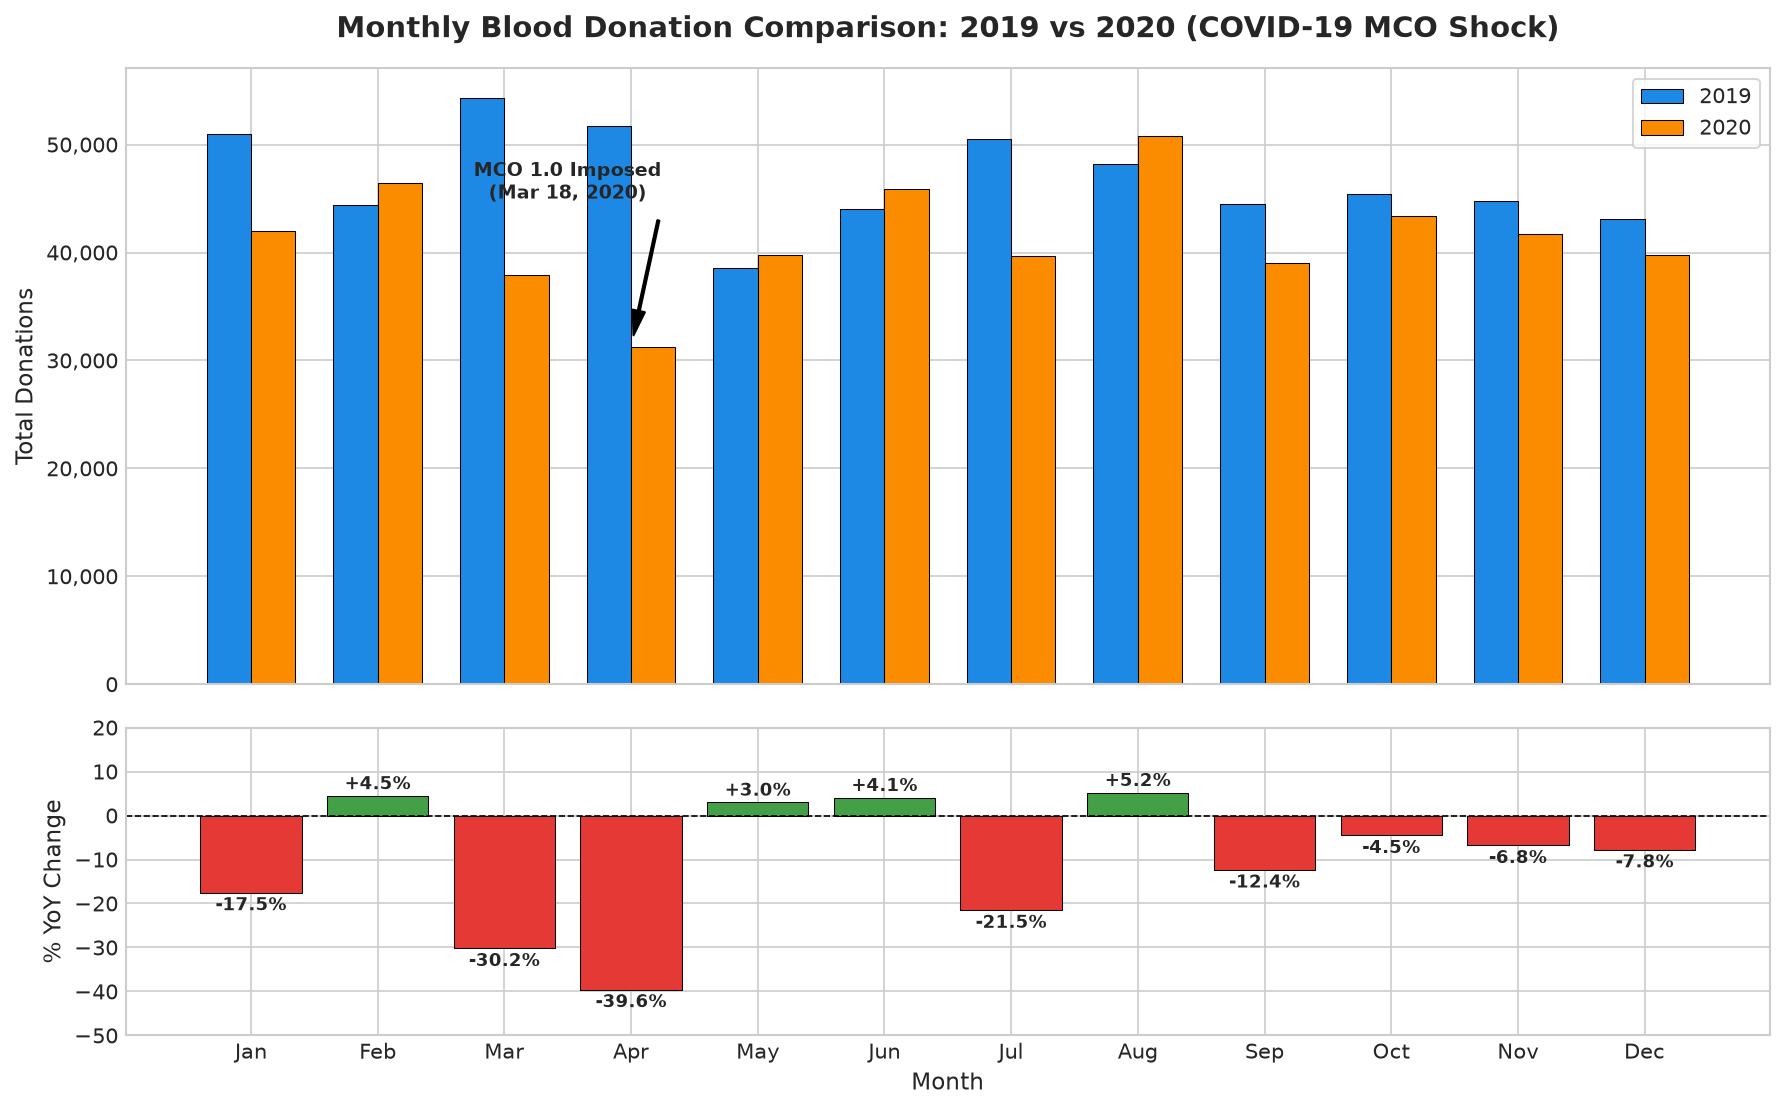

In [10]:
# 9. 2019 vs 2020 Monthly Comparison
df_state_nat = df_state[df_state["state"] == "Malaysia"].copy()
df_state_nat["date"] = pd.to_datetime(df_state_nat["date"])
df_state_nat["year"] = df_state_nat["date"].dt.year
df_state_nat["month"] = df_state_nat["date"].dt.month

df_19_20 = df_state_nat[df_state_nat["year"].isin([2019, 2020])].copy()
monthly_comp = df_19_20.groupby(["month", "year"])["daily"].sum().unstack()
monthly_comp["pct_change"] = ((monthly_comp[2020] - monthly_comp[2019]) / monthly_comp[2019]) * 100

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_comp["month_name"] = months

print("2019 vs 2020 Monthly Donation Comparison:")
for idx, m in enumerate(months, start=1):
    d19 = monthly_comp.loc[idx, 2019]
    d20 = monthly_comp.loc[idx, 2020]
    pct = monthly_comp.loc[idx, "pct_change"]
    print(f"  {m}: 2019 = {d19:,}, 2020 = {d20:,} ({pct:+.1f}%)")

x = np.arange(1, 13)
width = 0.35

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 7.5), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

# Bar Chart
rects1 = ax1.bar(
    x - width / 2,
    monthly_comp[2019],
    width,
    label="2019",
    color="#1e88e5",
    edgecolor="black",
    linewidth=0.5,
)
rects2 = ax1.bar(
    x + width / 2,
    monthly_comp[2020],
    width,
    label="2020",
    color="#fb8c00",
    edgecolor="black",
    linewidth=0.5,
)

ax1.set_title("Monthly Blood Donation Comparison: 2019 vs 2020 (COVID-19 MCO Shock)", pad=15)
ax1.set_ylabel("Total Donations")
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))
ax1.legend(loc="upper right", frameon=True)

# Annotate MCO onset
ax1.annotate(
    "MCO 1.0 Imposed\n(Mar 18, 2020)",
    xy=(4, monthly_comp.loc[4, 2020]),
    xytext=(3.5, 45000),
    arrowprops={"facecolor": "black", "shrink": 0.08, "width": 1, "headwidth": 6},
    fontsize=9,
    fontweight="bold",
    ha="center",
)

# Percentage Change Bar Chart
colors_pct = ["#e53935" if v < 0 else "#43a047" for v in monthly_comp["pct_change"]]
ax2.bar(x, monthly_comp["pct_change"], color=colors_pct, edgecolor="black", linewidth=0.5)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_ylabel("% YoY Change")
ax2.set_xlabel("Month")
ax2.set_xticks(x)
ax2.set_xticklabels(months)
ax2.set_ylim(-50, 20)

for idx, val in enumerate(monthly_comp["pct_change"]):
    y_pos = -48 if val < 0 else val + 1
    ax2.text(
        x[idx],
        val + (1.5 if val >= 0 else -4),
        f"{val:+.1f}%",
        ha="center",
        fontsize=8.5,
        fontweight="bold",
    )

plt.tight_layout()

fig_path_8 = FIGURES_DIR / "08_2019_vs_2020_monthly.png"
plt.savefig(fig_path_8)
plt.show()

**Takeaway (Figure 8):** When COVID-19 Movement Control Orders (MCO) were introduced in March 2020, donations plunged sharply by -30.2% in March (37,921 vs 54,340) and -39.6% in April (31,274 vs 51,745) compared to 2019. In addition to lockdown effects, major differences in January (-17.5%) and July (-21.5%) coincide with festival calendar movements between 2019 and 2020: Chinese New Year moved earlier from Feb 5 in 2019 to Jan 25 in 2020 (suppressing January 2020), while Hari Raya Aidilfitri moved from Jun 5 in 2019 to May 24 in 2020 (shifting post-Eid and Aidiladha recovery timing, with July 2020 registering 39,677 vs 50,562 in 2019). Subsequent months rebounded with June (+4.1%) and August (+5.2%) 2020 exceeding 2019 levels.
